In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from pathlib import Path 
import torch 

In [2]:
# Get model activation files 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB.h5")
path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v2.h5")

In [3]:
out_dir

PosixPath('binaural_model_attn_stage_reps')

In [4]:
acts =  h5py.File(path, 'r')
print(acts.keys())
layer_names = [key.split("_mixture")[0] for key in acts.keys() if "mixture" in key and 'acc' not in key]
print(layer_names)
print(len(layer_names))

### Test method that doesn't compute full covariance matrix
n_to_use = 10
# get mixture acts 
# layer = layer_names[1]
# mixture_acts = acts[f"{layer}_mixture"][:n_to_use, :]
# target_acts = acts[f"{layer}_fg"][:n_to_use, :]
# bg_acts = acts[f"{layer}_bg"][:n_to_use, :]

# trial_accs = acts['acc_mixture'][:]
# fg_accs = acts['acc_fg'][:]

# print(trial_accs[trial_accs!=-1].mean())
# print(fg_accs[fg_accs!=-1].mean())
# get mixture acts
# fg_r = np.corrcoef(mixture_acts, target_acts)
# matrix_corrs = np.diagonal(fg_r[:n_to_use, n_to_use:])
# try with pearsonr
# pearson_corrs = [stats.pearsonr(target_acts, mixture_acts)[0] for mixture_acts, target_acts in zip(mixture_acts, target_acts)]
# print(f"{layer} target corr {np.mean(pearson_corrs):.3f} {stats.sem(pearson_corrs):.3f}")

# # try with pearsonr
# pearson_corrs = [stats.pearsonr(bg_acts, mixture_acts)[0] for mixture_acts, bg_acts in zip(mixture_acts, bg_acts)]
# print(f"{layer} background corr {np.mean(pearson_corrs):.3f} {stats.sem(pearson_corrs):.3f}")

# print(f"{layer} background corr {np.mean(pearson_corrs):.3f} {stats.sem(pearson_corrs):.3f}")


acts.close()

<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

## Run full thing and save - will move to script in future 

In [14]:
with h5py.File(path, 'r') as f:
    # layer_names = [key.split("_mixture")[0] for key in f.keys() if "mixture" in key]
    layer_names = [key.split("_mixture")[0] for key in f.keys() if "mixture" in key and 'acc' not in key]

    print(layer_names)
    fg_corr_results = {}
    bg_corr_results = {}
    
    out_name = f"{path.stem}_corrs_high_perf_only.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)
    N_acts = f[f"{layer_names[0]}_mixture"].shape[0]
    for layer in layer_names:
        mixture_acts = f[f"{layer}_mixture"]
        target_acts = f[f"{layer}_fg"]
        bg_acts = f[f"{layer}_bg"]

        fg_corr_results[layer] = []
        bg_corr_results[layer] = []

        for i in tqdm(range(N_acts), desc=f"Getting activations for {layer}", leave=False):
            fg_corr_results[layer].append(stats.pearsonr(target_acts[i], mixture_acts[i])[0])
            bg_corr_results[layer].append(stats.pearsonr(bg_acts[i], mixture_acts[i])[0])
        
        # set type as float32
        fg_corr_results[layer] = np.array(fg_corr_results[layer], dtype=np.float32)
        bg_corr_results[layer] = np.array(bg_corr_results[layer], dtype=np.float32)
        
    out_dict = dict(fg_corr_results=fg_corr_results, bg_corr_results=bg_corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)

['cochleagram', 'conv_block_0', 'conv_block_1', 'conv_block_2', 'conv_block_3', 'conv_block_4', 'conv_block_5', 'conv_block_6', 'relufc']
binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_corrs_high_perf_only.pkl


Getting activations for cochleagram:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_0:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_1:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_2:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_4:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for conv_block_6:   0%|          | 0/100 [00:00<?, ?it/s]

Getting activations for relufc:   0%|          | 0/100 [00:00<?, ?it/s]

## Run null-correlation for sanity check 
Just compare any two unrelated target streams - gives floor for how correlated any two attended but un-related signals are. 



In [10]:
np.random.seed(0)

with h5py.File(path, 'r') as f:
    layer_names = [key.split("_mixture")[0] for key in f.keys() if "mixture" in key]
    print(layer_names)
    null_fg_fg_corr_results = {}
    null_fg_mixture_corr_results = {}

    out_name = f"{path.stem}_null_corrs.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)

    N_acts = f[f"{layer_names[0]}_mixture"].shape[0]
    n_boot = 10_000 
    
    for layer in layer_names:
        target_acts = f[f"{layer}_fg"]
        mixture_acts = f[f"{layer}_mixture"]

        # correlate each act against all other acts
        layer_fg_corrs = np.zeros(n_boot, dtype=np.float32)
        layer_mixture_corrs = np.zeros(n_boot, dtype=np.float32)

        for i in tqdm(range(n_boot), desc=f"Getting null activations for {layer}", leave=False):
            i,j = np.random.choice(N_acts, size=2, replace=False)
            layer_fg_corrs[i] = stats.pearsonr(target_acts[i], target_acts[j])[0]
            layer_mixture_corrs[i] = stats.pearsonr(target_acts[i], mixture_acts[j])[0]
        
        # set type as float32
        null_fg_fg_corr_results[layer] = {'mean': layer_fg_corrs.mean(), 'two_sem': 2*layer_fg_corrs.std()/np.sqrt(n_boot)}
        null_fg_mixture_corr_results[layer] = {'mean': layer_mixture_corrs.mean(), 'two_sem': 2*layer_mixture_corrs.std()/np.sqrt(n_boot)}
        
    out_dict = dict(null_fg_fg_corr_results=null_fg_fg_corr_results, null_fg_mixture_corr_results=null_fg_mixture_corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)

['cochleagram', 'conv_block_0', 'conv_block_1', 'conv_block_2', 'conv_block_3', 'conv_block_4', 'conv_block_5', 'conv_block_6', 'relufc']
binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_null_corrs.pkl


Getting null activations for cochleagram:   0%|          | 33/10000 [00:05<27:37,  6.01it/s]/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


KeyboardInterrupt: 

In [9]:
for (i,j) in np.random.choice(100, size=(10,2), replace=False):
    print(i,j)


57 93
64 69
79 70
31 2
32 39
74 53
35 14
63 87
23 25
89 1


In [15]:
## Make layer plot 

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pickle 
import pandas as pd


In [ ]:
# put results into dataframe
# put into df for easy plotting:

# load results

# # out_name = out_dir / f"{paths[0].stem}_corrs.pkl"
# with open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_corrs.pkl", 'rb') as f:
#     results = pickle.load(f)

# fg_corr_results = results['fg_corr_results']
# bg_corr_results = results['bg_corr_results']


dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
                                 'bg_corrs':bg_corr_results[layer],
                                 'acc': trial_accs, 
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

results = pd.melt(corr_results, id_vars =['layer', 'acc'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")


# # get null corrs 
# null_dir = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/")
# null_corr_pickles = list(null_dir.glob("*0dB*null_corrs.pkl"))

# dfs = []
# for null_corr_pickle in null_corr_pickles:
#     with open(null_corr_pickle, 'rb') as f:
#         null_results = pickle.load(f)

#     layer = null_corr_pickle.stem.split("0dB_")[1].split("_null")[0]

#     null_fg_fg_corr_results = null_results['null_fg_fg_corr_results']
#     null_fg_mixture_corr_results = null_results['null_fg_mixture_corr_results']
#     df = pd.DataFrame.from_dict({'null_fg_fg_corr_mean': [null_fg_fg_corr_results['mean']],
#                                  'null_fg_fg_corr_2_sem': [null_fg_fg_corr_results['two_sem']],
#                                  'null_fg_mixture_corr_mean': [null_fg_mixture_corr_results['mean']],
#                                  'null_fg_mixture_corr_2_sem': [null_fg_mixture_corr_results['two_sem']],
#                                  'layer': [layer]})
#     dfs.append(df)

# null_corr_df = pd.concat(dfs)

# null_corr_df['layer'] = null_corr_df['layer'].str.replace('_block_', '')

# # melt null_corr_df 
# null_corr_df_means = pd.melt(null_corr_df, id_vars =['layer'], value_vars=['null_fg_fg_corr_mean', 'null_fg_mixture_corr_mean'], var_name='Model',
#                             value_name="Pearson's r")
# # rename null model column 
# null_corr_df_means['Model'] = null_corr_df_means['Model'].str.replace('null_fg_fg_corr_mean', 'null corr(target, target)')
# null_corr_df_means['Model'] = null_corr_df_means['Model'].str.replace('null_fg_mixture_corr_mean', 'null corr(target, mixture)')
# # melt null_corr_df 
# null_corr_df_errors = pd.melt(null_corr_df, id_vars =['layer'], value_vars=['null_fg_fg_corr_2_sem', 'null_fg_mixture_corr_2_sem'], var_name='Model',
#                             value_name="two SEM")

# null_corr_df_errors['Model'] = null_corr_df_errors['Model'].str.replace('null_fg_fg_corr_2_sem', 'null corr(target, target)')
# null_corr_df_errors['Model'] = null_corr_df_errors['Model'].str.replace('null_fg_mixture_corr_2_sem', 'null corr(target, mixture)')
# # merge null_corr_df_means and null_corr_df_errors
# null_corr_df = null_corr_df_means.merge(null_corr_df_errors, on=['layer', 'Model'])

In [ ]:
results

,layer,Stream,Pearson's r
0,cochleagram,fg_corrs,0.694880
1,cochleagram,fg_corrs,0.631908
2,cochleagram,fg_corrs,0.717576
3,cochleagram,fg_corrs,0.505052
4,cochleagram,fg_corrs,0.679614
...,...,...,...
1795,relufc,bg_corrs,0.111098
1796,relufc,bg_corrs,0.212452
1797,relufc,bg_corrs,0.209730
1798,relufc,bg_corrs,0.340103


In [17]:
# summarize results and rename columns to Pearson's r and two SEM

summary_results = results.groupby(['layer', 'Stream']).agg(['mean', 'sem']).reset_index()
summary_results.columns = ['layer', 'Stream', "Pearson's r", 'two SEM']
# rename columns
summary_results = summary_results.rename(columns={"Stream": "Model"})

summary_results['two SEM'] = 2*summary_results['two SEM'] # actually get 2 sem 
# upate stream names 
summary_results['Model'] = summary_results['Model'].str.replace('fg_corrs', 'corr(target,mixture)')
summary_results['Model'] = summary_results['Model'].str.replace('bg_corrs', 'corr(background,mixture)')
# summary_results
# combine null_corr_df and summary_results
# combined_results = pd.concat([summary_results, null_corr_df], ignore_index=True)
# combined_results

Text(0.5, 0.98, 'Stream activation correlations with attention')

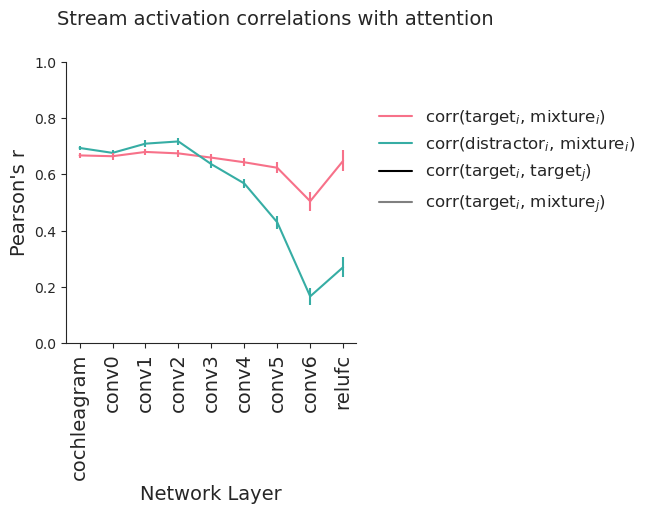

In [18]:
## Plot summary_results df 
sns.set_style('ticks')
order = np.sort(results.layer.unique())

summary_results['Model'].replace('corr(target,mixture)', 'corr(target$_i$, mixture$_i$)', inplace=True)
summary_results['Model'].replace('corr(background,mixture)', 'corr(distractor$_i$, mixture$_i$)', inplace=True)

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)', 'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[0],
                'corr(distractor$_i$, mixture$_i$)': palette[1],
                'corr(target$_i$, target$_j$)': 'k',
                'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',
                   'corr(target$_i$, target$_j$)': '--',
                   'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line',data=summary_results, x='layer', y="Pearson's r", #order=order,
              hue = 'Model', hue_order = hue_order, palette=palette_dict, 
              height=4, aspect=1, 
              errorbar=None, seed=1)

# add error bars to p 
for model, data in summary_results.groupby('Model'):
    # get the error bars
    yerr = data['two SEM'].values
    # get the x values
    x = data['layer'].values
    # get the y values
    y = data["Pearson's r"].values
    # plot the error bars
    p.axes[0][0].errorbar(x, y, yerr=yerr, fmt='none', color=palette_dict[model],  capthick=2)
    # p.axes[0][0].fill_between(x, y-yerr, y+yerr, alpha=0.25, color=palette_dict[model], linewidth=0)


fontsize=14


p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False,
                title='', fontsize=fontsize-2)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Stream activation correlations with attention", size=fontsize, )



Text(0.5, 0.98, 'Stream activation correlations with attention')

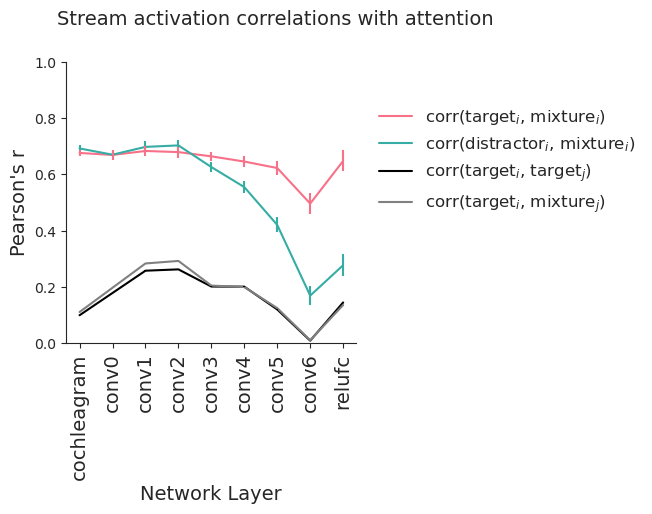

In [126]:
## Plot combined_results df 
sns.set_style('ticks')
order = np.sort(results.layer.unique())

# rename null corr(target, target) to null corr(target, target)
combined_results['Model'].replace('null corr(target, target)', 'corr(target$_i$, target$_j$)', inplace=True)
combined_results['Model'].replace('null corr(target, mixture)', 'corr(target$_i$, mixture$_j$)', inplace=True)

combined_results['Model'].replace('corr(target,mixture)', 'corr(target$_i$, mixture$_i$)', inplace=True)
combined_results['Model'].replace('corr(background,mixture)', 'corr(distractor$_i$, mixture$_i$)', inplace=True)

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)', 'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[0],
                'corr(distractor$_i$, mixture$_i$)': palette[1],
                'corr(target$_i$, target$_j$)': 'k',
                'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',
                   'corr(target$_i$, target$_j$)': '--',
                   'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line',data=combined_results, x='layer', y="Pearson's r", #order=order,
              hue = 'Model', hue_order = hue_order, palette=palette_dict, 
              height=4, aspect=1, 
              errorbar=None, seed=1)

# add error bars to p 
for model, data in combined_results.groupby('Model'):
    # get the error bars
    yerr = data['two SEM'].values
    # get the x values
    x = data['layer'].values
    # get the y values
    y = data["Pearson's r"].values
    # plot the error bars
    p.axes[0][0].errorbar(x, y, yerr=yerr, fmt='none', color=palette_dict[model],  capthick=2)
    # p.axes[0][0].fill_between(x, y-yerr, y+yerr, alpha=0.25, color=palette_dict[model], linewidth=0)


fontsize=14


p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False,
                title='', fontsize=fontsize-2)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Stream activation correlations with attention", size=fontsize, )



## Old style plots 

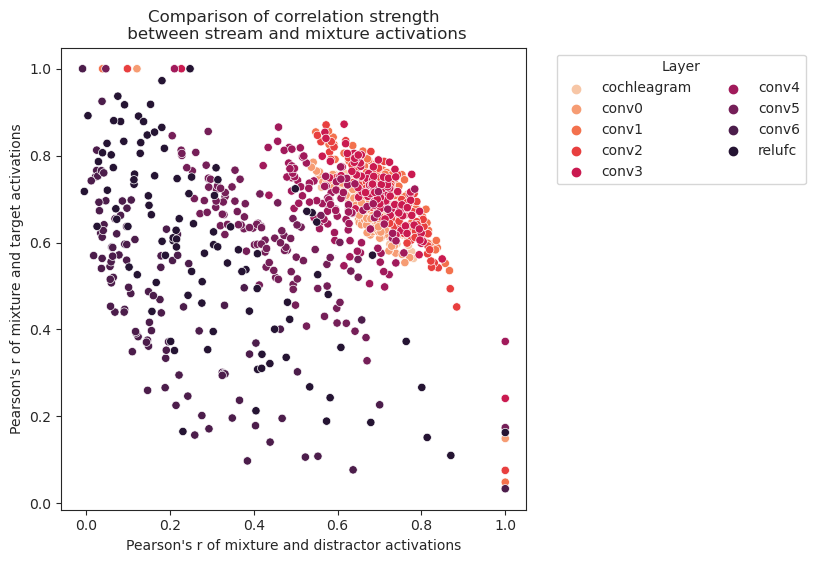

In [88]:

fig, axs = plt.subplots(1, figsize=(6,6))



# order = results.layer.unique()


sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs', hue_order=order,
                hue='layer', palette='rocket_r', ax=axs)

# sns.pointplot(data=results, x='layer', y="Pearson's r", order=order,
#               hue = 'Stream', palette='husl', ax=axs[1],
#              ci=95, n_boot=1000, seed=1)

axs.set_title("Comparison of correlation strength\n between stream and mixture activations")
axs.set_xlabel("Pearson's r of mixture and distractor activations")
axs.set_ylabel("Pearson's r of mixture and target activations")
axs.legend(title='Layer', ncol=2, frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
# axs[1].set_ylim(0,1)

# axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")
# rotate x labels for axis 1
# for ax in axs:
#     plt.sca(ax)
#     plt.xticks(rotation=90)

# plt.tight_layout()

In [89]:
results[results['Pearson\'s r'].isna()]

,layer,Stream,Pearson's r
80,cochleagram,target,NaN
969,cochleagram,distractor,NaN


In [17]:
to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)

              
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")


p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Stream activation correlations with attention", size=fontsize)


NameError: name 'order' is not defined

Text(0.5, 0.98, 'Standard training')

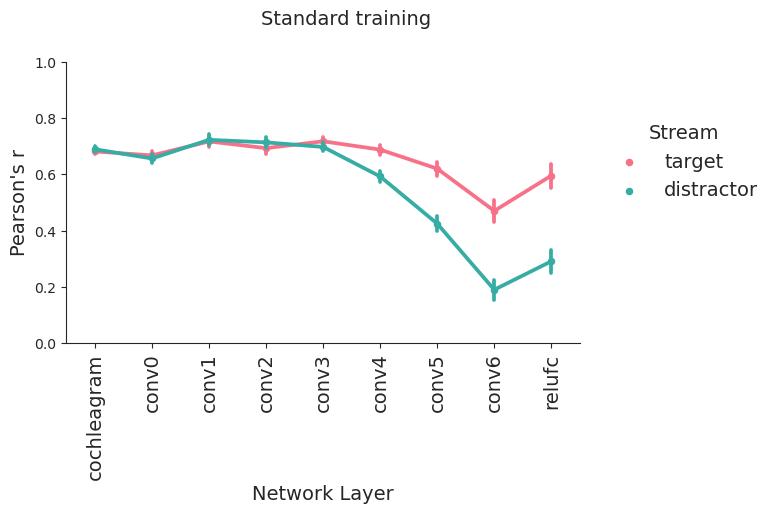

In [91]:
# to_plot = results[results['Pearson\'s r'].notna()]
# sns.set_style('ticks')

# p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
#               hue = 'Stream', palette='husl', 
#               height=4, aspect=1.5, markers='.',
#               errorbar=('se', 2), seed=1)
# fontsize=14

# # plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# # g.set_axis_labels("", "Prop. Contour Correct")

# p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# # set y limit to 0,1
# p.set(ylim=(0,1))

# p.set_xticklabels(rotation=90, size=fontsize)
# # g.set_yticklabels(size=fontsize)

# # plt.yscale('log')
# sns.move_legend(p,
#                 loc="center right", bbox_to_anchor=(1.1, .6),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# # plt.tick_params(axis='both', which='major', labelsize=16)
# p.fig.subplots_adjust(top=.85) # adjust the Figure in

# # p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
# p.fig.suptitle("Standard training", size=fontsize)
